Research Question 3: Environmental Drivers of Heat Risk
Which physical environmental characteristics are associated with neighbourhood heat risk?



In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt



In [13]:
# checking data set
df = pd.read_excel(
    "../Klimaatrisicokaarten/Excel ruwe data klimaatrisicokaarten.xlsx",
    header=6
)

print(df.head(10))

                        name  AA_KRA_TOTAAL_S.0  DR_AANPASSINGSVERMOGEN_S.0  \
0  RK_Tuindorp Oostzaan Oost               3.58                         3.5   
1          RK_Banne Zuidwest               3.56                         2.5   
2               RK_Kortvoort               3.48                         3.5   
3         RK_Jan Maijenbuurt               3.47                         5.0   
4                 RK_Buurt 3               3.44                         4.0   
5    RK_Louis Chrispijnbuurt               3.43                         4.0   
6          RK_K-buurt Midden               3.42                         4.5   
7       RK_Amsterdamse Poort               3.41                         4.5   
8    RK_Jacques Veltmanbuurt               3.41                         4.0   
9                 RK_De Punt               3.40                         4.0   

   DR_AV_MATE_VAN_VERHARDING_S.0  DR_AV_MATE_VAN_VERHARDING_V.0  \
0                            4.0                           67.0

In [14]:
# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Remove duplicate rows
df = df.drop_duplicates()

# Check dimensions
print("Shape:")
print(df.shape)

# Check missing values
missing = df.isna().sum()

print("\nColumns with missing values:")
print(missing[missing > 0].sort_values(ascending=False))

# Check data types
print("\nData types:")
print(df.dtypes)

# Summary statistics
print("\nSummary statistics:")
print(df.describe())

# Save cleaned dataset
df.to_csv("cleaned_climate_risk_data.csv", index=False)

print("\nCleaned dataset saved.")

Shape:
(500, 132)

Columns with missing values:
WO_GV_INWONERS_MOBILITEIT_V.0                16
WO_GV_AANTAL_LANGDURIG_ZIEKE_INWONERS_V.0    16
WV_GV_INWONERS_MOBILITEIT_V.0                16
HI_GV_INWONERS_BEPERKT_MOBIEL_V.0            16
HI_GV_AANTAL_LANGDURIG_ZIEKE_INWONERS_V.0    16
                                             ..
HI_BS_SCHADUW_OP_LOOPGEBIEDEN_S.0             2
HI_BS_DRUK_OPENBARE_RUIMTE_V.0                2
HI_BS_DRUK_OPENBARE_RUIMTE_S.0                2
WV_TOTAAL_S.0                                 2
DR_GV_HOOFD_GROEN_STRUCTUUR_V.0               1
Length: 132, dtype: int64

Data types:
name                                       object
AA_KRA_TOTAAL_S.0                         float64
DR_AANPASSINGSVERMOGEN_S.0                float64
DR_AV_MATE_VAN_VERHARDING_S.0             float64
DR_AV_MATE_VAN_VERHARDING_V.0             float64
                                           ...   
WV_KO_OVERSTROMINGSDIEPTE_1_X_1000_S.0    float64
WV_KO_OVERSTROMINGSDIEPTE_1_X_1000_

In [15]:
# %%
# HI = Hitte
# DR = Droogte
# WO = Wateroverlast
# WV = Waterveiligheid

heat_cols = sorted([c for c in df.columns if c.startswith("HI")])
print("\n".join(heat_cols))

# %% <--- ---> 

## EXTRACTING ALL HEAT VARIABLES

# Select all columns that start with HI (Hitte)
heat_cols = [c for c in df.columns if c.startswith("HI")]

print("\nHeat variables:")
for col in heat_cols:
    print(col)
    
# Creating a dataframe containing only the heat variables
heat_df = df[heat_cols]

# Show summary statistics
print("\nHeat variable summary:")
print(heat_df.describe())

# Calculate correlations between all heat variables
corr_matrix = heat_df.corr()

# Show strongest positive correlations with heat risk

corr_with_heat = (
    corr_matrix["HI_TOTAAL_S.0"]
    .sort_values(ascending=False)
)

print(corr_with_heat.head(15))
# %% <--- ---> 

# search for all physical variables 

physical_vars = [
    c for c in df.columns
    if any(
        keyword in c
        for keyword in [
            "VERHARDING",
            "GROEN",
            "WATER",
            "SCHADUW",
            "TUIN",
            "LATK"
        ]
    )
]

print("Physical variables:")
for col in physical_vars:
    print(col)
    
with open("heat_variables.txt", "w", encoding="utf-8") as f:
    for col in df.columns:
        if col.startswith("HI_"):
            f.write(col + "\n")

HI_AANPASSINGSVERMOGEN_S.0
HI_AV_LATK_S.0
HI_AV_LATK_V.0
HI_AV_TOEGANG_TOT_TUIN_S.0
HI_AV_TOEGANG_TOT_TUIN_V.0
HI_BLOOTSTELLING_S.0
HI_BS_AANTAL_INWONERS_V.0
HI_BS_ANTAL_INWONERS_S.0
HI_BS_DRUK_OPENBARE_RUIMTE_S.0
HI_BS_DRUK_OPENBARE_RUIMTE_V.0
HI_BS_SCHADUW_OP_LOOPGEBIEDEN_S.0
HI_BS_SCHADUW_OP_LOOPGEBIEDEN_V.0
HI_GEVOELIGHEID_S.0
HI_GV_AANTAL_65PLUS_S.0
HI_GV_AANTAL_65_INWONERS_V.0
HI_GV_AANTAL_LAAGOPGELEIDEN_V.0
HI_GV_AANTAL_LAAG_OPGELEIDEN_S.0
HI_GV_AANTAL_LANGDURIG_ZIEKE_INWONERS_S.0
HI_GV_AANTAL_LANGDURIG_ZIEKE_INWONERS_V.0
HI_GV_INWONERS_BEPERKT_MOBIEL_S.0
HI_GV_INWONERS_BEPERKT_MOBIEL_V.0
HI_GV_INWONERS_ONDER_SOCIAAL_MINIMUM_S.0
HI_GV_INWONERS_ONDER_SOCIAAL_MINIMUM_V.0
HI_GV_PANDEN_MET_KWETSBARE_GROEPEN_S.0
HI_GV_PANDEN_MET_KWETSBARE_GROEPEN_V.0
HI_KLIMAATOMSTANDIGHEID_S.0
HI_KO_PET_S.0
HI_KO_PET_V.0
HI_TOTAAL_S.0

Heat variables:
HI_AANPASSINGSVERMOGEN_S.0
HI_AV_LATK_S.0
HI_AV_LATK_V.0
HI_AV_TOEGANG_TOT_TUIN_S.0
HI_AV_TOEGANG_TOT_TUIN_V.0
HI_BLOOTSTELLING_S.0
HI_BS_AANTAL_INWON

In [16]:
# variables that can be used for 
#  x: HI_TOTAAL_S.0
#  y: DR_AV_MATE_VAN_VERHARDING_V.0
#     DR_BS_GROEN_PUBLIEK_V.0
#     DR_BS_GROEN_PRIVAAT_V.0
#     WO_GV_OPPERVLAKTE_WATER_V.0
#     HI_BS_SCHADUW_OP_LOOPGEBIEDEN_V.0
#     HI_AV_TOEGANG_TOT_TUIN_V.0

# correlation 
target = "HI_TOTAAL_S.0"

policy_vars = [
    "DR_AV_MATE_VAN_VERHARDING_V.0",
    "DR_BS_GROEN_PUBLIEK_V.0",
    "DR_BS_GROEN_PRIVAAT_V.0",
    "WO_GV_OPPERVLAKTE_WATER_V.0",
    "HI_BS_SCHADUW_OP_LOOPGEBIEDEN_V.0",
    "HI_AV_TOEGANG_TOT_TUIN_V.0"
]

for var in policy_vars:
    print(var)
    print(df[target].corr(df[var]))
    print()

DR_AV_MATE_VAN_VERHARDING_V.0
0.38086151351777653

DR_BS_GROEN_PUBLIEK_V.0
-0.36259103117475394

DR_BS_GROEN_PRIVAAT_V.0
-0.21547561164944856

WO_GV_OPPERVLAKTE_WATER_V.0
-0.15966399023724262

HI_BS_SCHADUW_OP_LOOPGEBIEDEN_V.0
-0.07190680174727314

HI_AV_TOEGANG_TOT_TUIN_V.0
-0.001765189805174891



In [17]:
# %% <--- ---> OLS REGRESSION 

df = df.dropna(axis=1, how="all")
df = df.drop_duplicates()

variables = [
    "HI_TOTAAL_S.0",
    "DR_AV_MATE_VAN_VERHARDING_V.0",
    "DR_BS_GROEN_PUBLIEK_V.0",
    "DR_BS_GROEN_PRIVAAT_V.0",
    "WO_GV_OPPERVLAKTE_WATER_V.0"
]

model_df = df[variables].dropna()

y = model_df["HI_TOTAAL_S.0"]

X = model_df[
    [
        "DR_AV_MATE_VAN_VERHARDING_V.0",
        "DR_BS_GROEN_PUBLIEK_V.0",
        "DR_BS_GROEN_PRIVAAT_V.0",
        "WO_GV_OPPERVLAKTE_WATER_V.0"
    ]
]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          HI_TOTAAL_S.0   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     23.60
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           7.14e-18
Time:                        12:39:40   Log-Likelihood:                -258.60
No. Observations:                 498   AIC:                             527.2
Df Residuals:                     493   BIC:                             548.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)


                        Variable         VIF
0                          const  496.363571
1  DR_AV_MATE_VAN_VERHARDING_V.0   17.882548
2        DR_BS_GROEN_PUBLIEK_V.0    9.912456
3        DR_BS_GROEN_PRIVAAT_V.0    1.441488
4    WO_GV_OPPERVLAKTE_WATER_V.0    6.507597


In [21]:
# EASIER MODELS regression 

#1. impervious surface 
y = df["HI_TOTAAL_S.0"]

X = df[["DR_AV_MATE_VAN_VERHARDING_V.0"]]

X = sm.add_constant(X)

model_impervious = sm.OLS(
    y,
    X,
    missing="drop"
).fit()

print(model_impervious.summary())

# public green space 
y = df["HI_TOTAAL_S.0"]

X = df[["DR_BS_GROEN_PUBLIEK_V.0"]]

X = sm.add_constant(X)

model_green = sm.OLS(
    y,
    X,
    missing="drop"
).fit()

print(model_green.summary())

# surface water 
y = df["HI_TOTAAL_S.0"]

X = df[["WO_GV_OPPERVLAKTE_WATER_V.0"]]

X = sm.add_constant(X)

model_water = sm.OLS(
    y,
    X,
    missing="drop"
).fit()

print(model_water.summary())

# table 

results = pd.DataFrame({
    "Variable": [
        "Impervious Surface",
        "Public Green",
        "Surface Water"
    ],
    "R2": [
        model_impervious.rsquared,
        model_green.rsquared,
        model_water.rsquared
    ],
    "P-value": [
        model_impervious.pvalues[1],
        model_green.pvalues[1],
        model_water.pvalues[1]
    ]
})

print(results)




                            OLS Regression Results                            
Dep. Variable:          HI_TOTAAL_S.0   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     84.15
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.23e-18
Time:                        13:00:03   Log-Likelihood:                -263.20
No. Observations:                 498   AIC:                             530.4
Df Residuals:                     496   BIC:                             538.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

C:\Users\bisso\AppData\Local\Temp\ipykernel_2544\4010776760.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_impervious.pvalues[1],
C:\Users\bisso\AppData\Local\Temp\ipykernel_2544\4010776760.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_green.pvalues[1],
C:\Users\bisso\AppData\Local\Temp\ipykernel_2544\4010776760.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_water.pvalues[1]


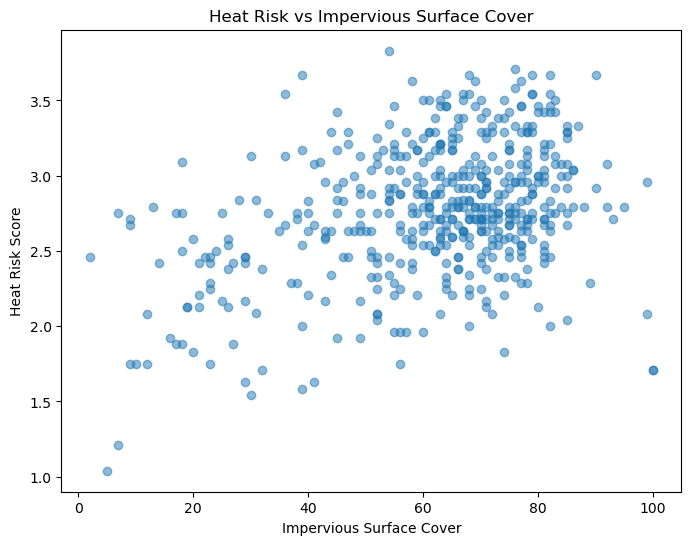

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["DR_AV_MATE_VAN_VERHARDING_V.0"],
    df["HI_TOTAAL_S.0"],
    alpha=0.5
)

plt.xlabel("Impervious Surface Cover")
plt.ylabel("Heat Risk Score")
plt.title("Heat Risk vs Impervious Surface Cover")

plt.show()

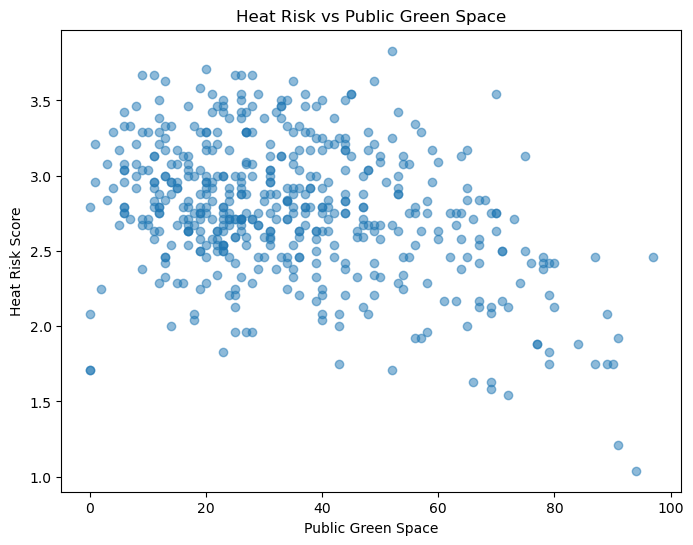

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["DR_BS_GROEN_PUBLIEK_V.0"],
    df["HI_TOTAAL_S.0"],
    alpha=0.5
)

plt.xlabel("Public Green Space")
plt.ylabel("Heat Risk Score")
plt.title("Heat Risk vs Public Green Space")

plt.show()

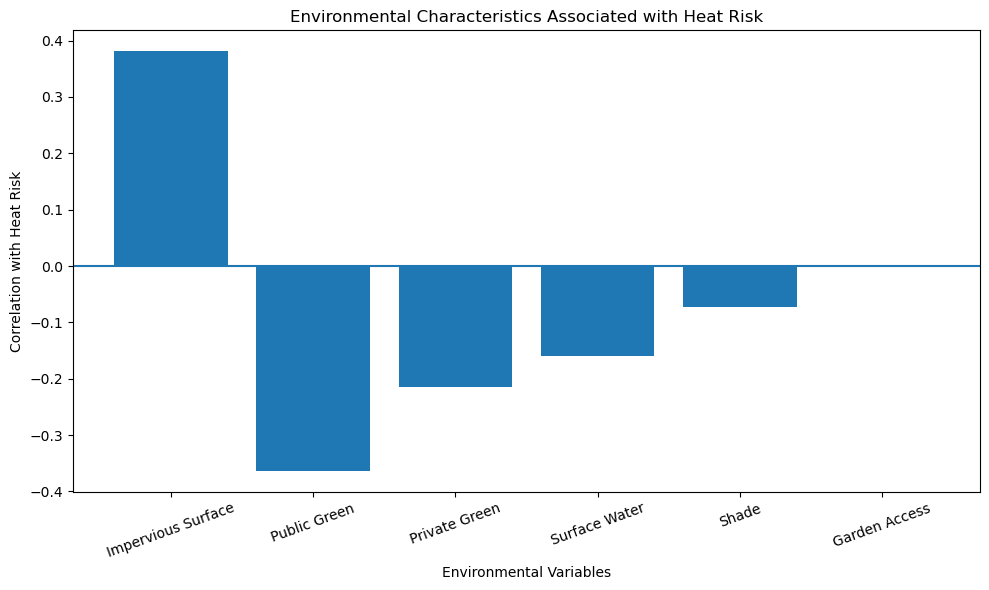

In [25]:


# Data
variables = [
    "Impervious Surface",
    "Public Green",
    "Private Green",
    "Surface Water",
    "Shade",
    "Garden Access"
]

correlations = [
    0.381,
    -0.363,
    -0.215,
    -0.160,
    -0.072,
    -0.002
]

# Create figure
plt.figure(figsize=(10, 6))

# Bar chart
plt.bar(
    variables,
    correlations
)

# Labels and title
plt.xlabel("Environmental Variables")
plt.ylabel("Correlation with Heat Risk")
plt.title("Environmental Characteristics Associated with Heat Risk")

# Rotate labels
plt.xticks(rotation=20)

# Add horizontal line at zero
plt.axhline(0)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

In [26]:
### Creating a CSV output for the map

df["heat_norm"] = (
    df["HI_TOTAAL_S.0"].rank(pct=True)
)

df["impervious_norm"] = (
    df["DR_AV_MATE_VAN_VERHARDING_V.0"].rank(pct=True)
)

df["green_norm"] = (
    df["DR_BS_GROEN_PUBLIEK_V.0"].rank(pct=True)
)

# Intervention priority score

df["intervention_priority"] = (
    0.4 * df["heat_norm"]
    + 0.4 * df["impervious_norm"]
    - 0.2 * df["green_norm"]
)

In [27]:
df["priority_class"] = pd.qcut(
    df["intervention_priority"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [28]:
priority = (
    df[
        [
            "name",
            "HI_TOTAAL_S.0",
            "DR_AV_MATE_VAN_VERHARDING_V.0",
            "DR_BS_GROEN_PUBLIEK_V.0",
            "intervention_priority",
            "priority_class"
        ]
    ]
    .sort_values(
        "intervention_priority",
        ascending=False
    )
)

print(priority.head(20))

                                         name  HI_TOTAAL_S.0  \
7                        RK_Amsterdamse Poort           3.67   
13                        RK_Balboaplein e0o0           3.67   
361                            RK_Markthallen           3.33   
208                        RK_Spuistraat Zuid           3.50   
308                       RK_Spuistraat Noord           3.33   
276                  RK_Hercules Seghersbuurt           3.29   
311                      RK_Haveneiland Noord           3.42   
27                                 RK_F-buurt           3.46   
29                        RK_Dapperbuurt Zuid           3.54   
181                  RK_Haveneiland Noordwest           3.25   
333                               RK_Nes e0o0           3.08   
397                      RK_Nieuwendijk Noord           3.21   
104                            RK_Borgerbuurt           3.63   
142                     RK_Steigereiland Zuid           3.29   
84                       RK_Bellamybuurt

In [29]:
priority.to_csv(
    "intervention_priority.csv",
    index=False
)

print("CSV exported.")

CSV exported.


Research Question 4

Which neighbourhoods have the greatest potential for heat-risk reduction through environmental interventions?

In [30]:
#normalizing the variables 

df["heat_norm"] = (
    df["HI_TOTAAL_S.0"].rank(pct=True)
)

df["impervious_norm"] = (
    df["DR_AV_MATE_VAN_VERHARDING_V.0"].rank(pct=True)
)

df["green_norm"] = (
    df["DR_BS_GROEN_PUBLIEK_V.0"].rank(pct=True)
)

In [31]:
# intervention priority score 
df["intervention_priority"] = (
    df["heat_norm"]
    + df["impervious_norm"]
    - df["green_norm"]
)

# High Heat Risk
# +
# High Impervious Surface
# -
# Public Green Space
# =
# High Intervention Priority

In [ ]:
# priority class 
df["priority_class"] = pd.qcut(
    df["intervention_priority"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [33]:
rq4_output = df[
    [
        "name",
        "HI_TOTAAL_S.0",
        "DR_AV_MATE_VAN_VERHARDING_V.0",
        "DR_BS_GROEN_PUBLIEK_V.0",
        "intervention_priority",
        "priority_class"
    ]
]

rq4_output = rq4_output.sort_values(
    "intervention_priority",
    ascending=False
)

print(rq4_output.head(20))

                                         name  HI_TOTAAL_S.0  \
7                        RK_Amsterdamse Poort           3.67   
361                            RK_Markthallen           3.33   
13                        RK_Balboaplein e0o0           3.67   
308                       RK_Spuistraat Noord           3.33   
208                        RK_Spuistraat Zuid           3.50   
311                      RK_Haveneiland Noord           3.42   
276                  RK_Hercules Seghersbuurt           3.29   
333                               RK_Nes e0o0           3.08   
397                      RK_Nieuwendijk Noord           3.21   
181                  RK_Haveneiland Noordwest           3.25   
27                                 RK_F-buurt           3.46   
350                         RK_Kalverdriehoek           3.08   
340                       RK_Nieuwe Kerk e0o0           2.96   
104                            RK_Borgerbuurt           3.63   
84                       RK_Bellamybuurt

In [ ]:

rq4_output.to_csv(
    "intervention_priority.csv",
    index=False
)

print("RQ4 output saved.")

RQ4 output saved.
